<a href="https://colab.research.google.com/github/mib-a/AI-ML-Learning/blob/main/mib-a/AI-ML-Learning/Month-03-Deep-Learning/Backpropagation%20/Module-09/XOR_ANN_with_Numpyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Agenda:

Backpropagation on a neural network through numpy only on an XOR dataset.
- Dataset Specification:
  - Input Layer (2 nodes), 1 hidden layer (4 neurons), Ouput Layer (1 neuron)

- Why XOR? -> Not Linearly Separable, so need multiple layer Neural Network or Perceptron for that
- work flow:
  - Dataset building and target separation
  - Weights and Bias Initialization
  - Activation Function writing and their derivatives
  - Forward Propagation
  - Loss Calculation
  - Back Propagation
  - Bias and Weights updation
  - Looping with Epoch's value
  - Loss Visualization


In [104]:
import numpy as np

##XOR Dataset


| Input 1 | Input 2 | Target (XOR Output) |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |


In [105]:
# as the table above (text cell)

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)   # shape (4,2)
y = np.array([[0],[1],[1],[0]], dtype=float)            # shape (4,1)

print(f"Shape of X: {X.shape} \nShape of y: {y.shape}") # follow the table above


Shape of X: (4, 2) 
Shape of y: (4, 1)


## Weights and Bias Initialization

Draw the Neural Network first for better understanding

In [106]:
n_input , n_hidden , n_output = 2 , 4 , 1  # suppose

np.random.seed(42) # setting the global seed

w1 = np.random.randn(n_input, n_hidden) * 0.5 # going from input layer to 1st hidden layer, integers 1-10
#w1 = np.random.randint(1, 11, size=(n_input , n_hidden)) # going from input layer to 1st hidden layer, integers 1-10
b1 = np.zeros((1, n_hidden)) # one bias per hidden neuron (4 neuron in the hidden layer_1)

w2 = np.random.randn(n_hidden , n_output) * 0.5 # going from 1st hidden layer to output layer
# w2 = np.random.randint(1, 11, size=(n_hidden , n_output))
b2 = np.zeros((1, n_output))

print(f"Shape of w1: {w1.shape} \nShape of b1: {b1.shape}")
print(f"Shape of w2: {w2.shape} \nShape of b2: {b2.shape}")

Shape of w1: (2, 4) 
Shape of b1: (1, 4)
Shape of w2: (4, 1) 
Shape of b2: (1, 1)


- W1 connects the 2 input features to the 4 hidden neurons → shape (2,4) because X (4,2) @ W1 (2,4) = (4,4).
- We multiply the random init by 0.5 to keep initial activations small (avoids saturating sigmoid immediately). -> removed fractions for hand calculation

###All weights and biases

In [107]:
print(f"w1: {w1}")
print(f"\nb1: {b1}")
print(f"\nw2: {w2}")
print(f"\nb2: {b2}")

w1: [[ 0.24835708 -0.06913215  0.32384427  0.76151493]
 [-0.11707669 -0.11706848  0.78960641  0.38371736]]

b1: [[0. 0. 0. 0.]]

w2: [[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]

b2: [[0.]]


##Activation Function and Their Derivatives

### Sigmoid Activation Function

#### Sigmoid Activation Function

The standard logistic sigmoid function:

$$f(x) = \sigma(x) = \frac{1}{1 + e^{-x}}$$

#### Derivative of the Sigmoid Function

To find the derivative $\frac{d}{dx}\sigma(x)$, we can use the **Quotient Rule** $\left( \frac{u}{v} \right)' = \frac{u'v - uv'}{v^2}$ or the **Chain Rule**.

$$\frac{d}{dx}\sigma(x) = -1 \cdot (1 + e^{-x})^{-2} \cdot \frac{d}{dx}(1 + e^{-x})$$

as, $e^{-x}$ is $-e^{-x}$:
$$\frac{d}{dx}\sigma(x) = -(1 + e^{-x})^{-2} \cdot (-e^{-x})$$

$$\frac{d}{dx}\sigma(x) = \frac{e^{-x}}{(1 + e^{-x})^2}$$

Expressing the derivative in terms of sigmoid function:
$$\frac{d}{dx}\sigma(x) = \left( \frac{1}{1 + e^{-x}} \right) \cdot \left( \frac{e^{-x}}{1 + e^{-x}} \right)$$

Now,
$$\frac{e^{-x}}{1 + e^{-x}} = \frac{1 + e^{-x} - 1}{1 + e^{-x}} = \frac{1 + e^{-x}}{1 + e^{-x}} - \frac{1}{1 + e^{-x}} = 1 - \frac{1}{1 + e^{-x}}$$

Substitute this back:
$$\frac{d}{dx}\sigma(x) = \left( \frac{1}{1 + e^{-x}} \right) \cdot \left( 1 - \frac{1}{1 + e^{-x}} \right)$$

Final Simplified Form: (so we don't have to recompute exponentials)

$$\frac{d}{dx}\sigma(x) = \sigma(x)(1 - \sigma(x))$$


###ReLU

IGNORE the code below. Just study the graphs.

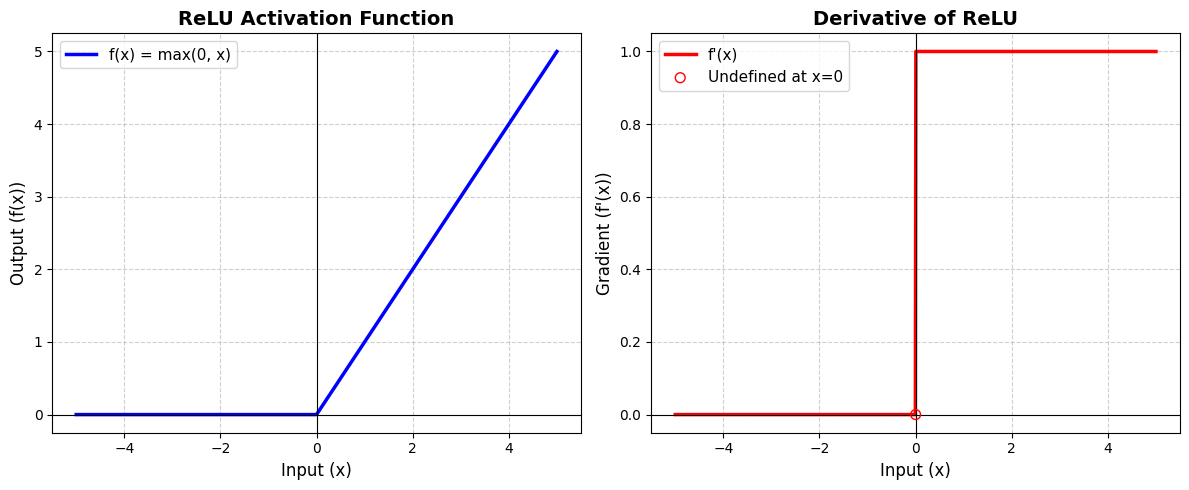

In [108]:
import matplotlib.pyplot as plt

# Define the ReLU function
def relu(x):
    return np.maximum(0, x)

# Define the derivative of ReLU
def relu_derivative(x):
    return np.where(x >= 0, 1, 0)

# Generate data points from -5 to 5
x = np.linspace(-5, 5, 1000)
y_relu = relu(x)
y_drop = relu_derivative(x)

# Create a side-by-side plot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: ReLU Function
ax1.plot(x, y_relu, label='f(x) = max(0, x)', color='blue', linewidth=2.5)
ax1.set_title('ReLU Activation Function', fontsize=14, fontweight='bold')
ax1.set_xlabel('Input (x)', fontsize=12)
ax1.set_ylabel('Output (f(x))', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.legend(fontsize=11)

# Plot 2: Derivative of ReLU
ax2.plot(x, y_drop, label="f'(x)", color='red', linewidth=2.5)
ax2.set_title('Derivative of ReLU', fontsize=14, fontweight='bold')
ax2.set_xlabel('Input (x)', fontsize=12)
ax2.set_ylabel("Gradient (f'(x))", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
# Visual marker for the discontinuity at x=0
ax2.scatter(0, 0, facecolors='none', edgecolors='red', s=50, zorder=5, label='Undefined at x=0')
ax2.legend(fontsize=11)

# Adjust layout and display
plt.tight_layout()
plt.show()


### Implementation of Activation Function (ACT)

In [109]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a): # a = sigmoid(z); return of the fn sigmoid(z)
    return a * (1-a)

def relu(z):
    return np.maximum(0,z) # zeroes out negative values, passes positive ones

def relu_derivative(z):
    return (z>0).astype(float) #returns 1 wherever the pre-activation was positive, 0 otherwise

1. We are using ReLU here to avoid gradient vanishing.
- the 2 input will be (0,0) once so Z1 = [0 0 0 0]. that's why relu is important for this problem
2. Using Sigmoid as it is a binary classification problem.

##Forward Propagation

In [110]:
def forward(X):
    Z1 = X @ w1 + b1          # (4,2)@(2,4) + (1,4) -> (4,4) # linear transform of the input
    #print(f"Z1 = X @ w1 + b1 = \n{Z1}")
    A1 = relu(Z1)              # (4,4) # hidden layer activation
    #print(f"\nA1 = relu(Z1) = \n{A1}")
    Z2 = A1 @ w2 + b2         # (4,4)@(4,1) + (1,1) -> (4,1) # hidden to output
    #print(f"\nZ2 = A1 @ w2 + b2 = \n{Z2}")
    A2 = sigmoid(Z2)           # (4,1)  <- final prediction # final prediction (0-1 probability)
    #print(f"\nA2 = sigmoid(Z2) = \n{A2}")
    cache = (Z1, A1, Z2, A2) # stores every intermediate values (Z1, A1, Z2, A2)
    return cache

In [111]:
forward(X)

(array([[ 0.        ,  0.        ,  0.        ,  0.        ],
        [-0.11707669, -0.11706848,  0.78960641,  0.38371736],
        [ 0.24835708, -0.06913215,  0.32384427,  0.76151493],
        [ 0.13128039, -0.18620063,  1.11345068,  1.14523229]]),
 array([[0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.78960641, 0.38371736],
        [0.24835708, 0.        , 0.32384427, 0.76151493],
        [0.13128039, 0.        , 1.11345068, 1.14523229]]),
 array([[ 0.        ],
        [-0.27231309],
        [-0.3106663 ],
        [-0.55549714]]),
 array([[0.5       ],
        [0.43233932],
        [0.42295211],
        [0.36458997]]))

## Loss Function (Binary Cross Entropy)

$$\text{BCE} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

for this specific problem:

$A2 = prediction$ &
$y = \text{target value}$

$$\text{BCE} = - \frac{1}{N} \sum \left[ y \log(A2) + (1 - y) \log(1 - A2) \right]$$




In [112]:
def compute_loss(A2, y): # final output (A2), target (y)
    n = y.shape[0] # number of samples for mean
    # Binary cross-entropy
    loss = -np.mean(y * np.log(A2 + 1e-8) + (1 - y) * np.log(1 - A2 + 1e-8)) # the formula above
    return loss

Binary cross-entropy: penalizes confident wrong predictions heavily. 1e-8 is added inside the log purely to avoid log(0) (numerical stability), it doesn't change the math meaningfully.

So, basically $log(0) => log(0+1e-8)$ # which is a very small number.

## Backpropagation



### Mathematical Derivation For Backpropagation

#### Output Layer $(\frac{\partial L}{\partial w2})$:

---

##Output Layer Gradient ($dZ_2$)
Chain Rule:
$$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial W_2}$$

So,

$$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial A_2} \cdot \frac{\partial A_2}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial W_2}$$


Now,
($\frac{\partial L}{\partial A_2}$):

$$\frac{\partial L}{\partial A_2} = -\frac{1}{n}\left( \frac{y}{A_2} - \frac{1 - y}{1 - A_2} \right) = \frac{1}{n}\frac{A_2 - y}{A_2(1 - A_2)}$$

Derivative of Sigmoid w.r.t. Pre-activation ($\frac{\partial A_2}{\partial Z_2}$), Using the Quotient Rule on $A_2 = \frac{1}{1 + e^{-Z_2}}$:

$$\frac{\partial A_2}{\partial Z_2} = \frac{e^{-Z_2}}{(1 + e^{-Z_2})^2} = \left(\frac{1}{1 + e^{-Z_2}}\right) \left(\frac{e^{-Z_2}}{1 + e^{-Z_2}}\right) = A_2(1 - A_2)$$

$\frac{dL}{dZ2}: $

$$\frac{\partial L}{\partial Z_2} = \frac{1}{n}\left( \frac{A_2 - y}{A_2(1 - A_2)} \right) \cdot A_2(1 - A_2)$$

$$\mathbf{dZ_2 = \frac{1}{n}(A_2 - y)}$$

Since $Z_2 = A_1 W_2 + b_2$, the derivative with respect to $W_2$ is $A_1$:
$$\frac{\partial Z_2}{\partial W_2} = A_1$$

---

##Output Layer Weights ($dW_2$) and Bias ($db_2$)

Now,
Transposing matrix dimensions to match shape $(n_{\text{hidden}} \times n_{\text{output}})$:
$$\mathbf{\frac{\partial L}{\partial w_2} = A_1^T \cdot dZ_2}$$

For $b_2$, since $\frac{\partial Z_2}{\partial b_2} = 1$:
$$\mathbf{\frac{\partial L}{\partial b_2} = \frac{1}{m} \sum_{\text{rows}} dZ_2}$$

#### Hidden Layer

##Backpropagating Loss to Hidden Layer ($dA_1$)
To find how much hidden layer activation $A_1$ contributed to the total loss:
$$dA_1 = \frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1}$$

Considering, $\frac{\partial Z_2}{\partial A_1} = W_2$;
$$\mathbf{dA_1 = dZ_2 \cdot W_2^T}$$

---

## Hidden Layer Pre-activation Gradient ($dZ_1$)

Chain Rule through the ReLU activation function:
$$dZ_1 = \frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} = dA_1 \cdot \text{ReLU}'(Z_1)$$

Derivative of ReLU ($\text{ReLU}(Z_1) = \max(0, Z_1)$):
$$\text{ReLU}'(Z_1) = \begin{cases} 1 & \text{if } Z_1 > 0 \\ 0 & \text{if } Z_1 \le 0 \end{cases}$$

Using element-wise multiplication ($\odot$):
$$\mathbf{dZ_1 = dA_1 \odot (Z_1 > 0)}$$
Now, this is already done in relu_derivative function, so relu_derivative(Z1)

---

## Hidden Layer Weights ($dW_1$) and Bias ($db_1$)

Applying the Chain Rule for the first layer parameters:
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1}$$

Since $Z_1 = X W_1 + b_1$, the derivative w.r.t. $W_1$ is $X$:
$$\frac{\partial Z_1}{\partial W_1} = X$$

Transposing $X$ to get dimensions $(n_{\text{input}} \times n_{\text{hidden}})$:
$$\mathbf{dW_1 = X^T \cdot dZ_1}$$

For bias $b_1$, summing the errors across all samples:
$$\mathbf{db_1 = \sum_{\text{rows}} dZ_1}$$



### Code

In [113]:
def backward(X , y , cache):
  Z1 , A1 , Z2 , A2 = cache # taking every variables from cache

  n = X.shape[0] # total batch/sample size

  #output layer gradient calculate
  dl_dZ2  = (A2 - y) / n

  # output layer weights and bias
  dl_dW2 = (A1.T @ dl_dZ2)
  dl_db2 = np.sum(dl_dZ2, axis = 0 , keepdims =  True) # Bias affects every sample equally with a constant derivative of 1, so we simply sum up all sample errors.

  #hidden layer

  dl_dA1 = dl_dZ2 @ w2.T # To find how much hidden layer activation  𝐴1  contributed to the total loss
  dl_dZ1 = dl_dA1 * relu_derivative(Z1) # Hidden Layer Pre-activation Gradient ( 𝑑𝑍1 )
  # Hidden Layer Weights ( 𝑑𝑊1 ) and Bias ( 𝑑𝑏1 )
  dl_dW1 = (X.T @ dl_dZ1)
  dl_db1 = np.sum(dl_dZ1 , axis = 0 , keepdims= True)



  grads = {"dW1": dl_dW1, "db1": dl_db1 , "dW2": dl_dW2  , "db2": dl_db2}

  return grads

In [114]:
returned_cache = forward(X)
A2 = returned_cache[3] # A2 is the last element in the cache tuple
cache = returned_cache

# 2. Call the backward function with X, y, and cache
grads = backward(X, y, cache)

In [115]:
grads

{'dW1': array([[ 0.01246794,  0.        ,  0.01230709,  0.0123685 ],
        [-0.02139571,  0.        ,  0.01176332,  0.01182201]]),
 'db1': array([[0.01246794, 0.        , 0.04519009, 0.04541555]]),
 'dW2': array([[-0.0238626 ],
        [ 0.        ],
        [-0.0572873 ],
        [-0.05992791]]),
 'db2': array([[-0.07002965]])}

## Parameter Updating Function

In [116]:
def update_params(grads, lr=0.5):

    global w1, b1, w2, b2

    w1 -= lr * grads["dW1"] # w1(new) = w1(old) - learning rate*dL/dw1
    b1 -= lr * grads["db1"]
    w2 -= lr * grads["dW2"]
    b2 -= lr * grads["db2"]

classic gradient descent — for every parameter, move it a small step (lr, the learning rate) in the opposite direction of its gradient, because the gradient points toward increasing loss and we want to decrease it.

## Epoch loop over the whole process

In [117]:
losses = []

for epoch in range(5000):
    # Step 1: Forward Pass (get predictions & cache)
    returned_cache = forward(X) # Assign the single returned tuple to a variable
    A2 = returned_cache[3]      # A2 is the fourth element (index 3) of the cache tuple
    cache = returned_cache      # The full cache is the returned_cache

    # Step 2: Compute Loss
    loss = compute_loss(A2, y)

    # Step 3: Backward Pass (call backward function)
    grads = backward(X, y, cache)

    # Step 4: Update Parameters
    update_params(grads, lr=0.5)

    losses.append(loss)

    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}  loss {loss:.4f}")

print("\nFinal predictions:")
print(np.round(A2, 3))

epoch     0  loss 0.7114
epoch  1000  loss 0.4777
epoch  2000  loss 0.4776
epoch  3000  loss 0.4775
epoch  4000  loss 0.4774

Final predictions:
[[0.667]
 [0.667]
 [0.667]
 [0.   ]]


## Loss Visualization

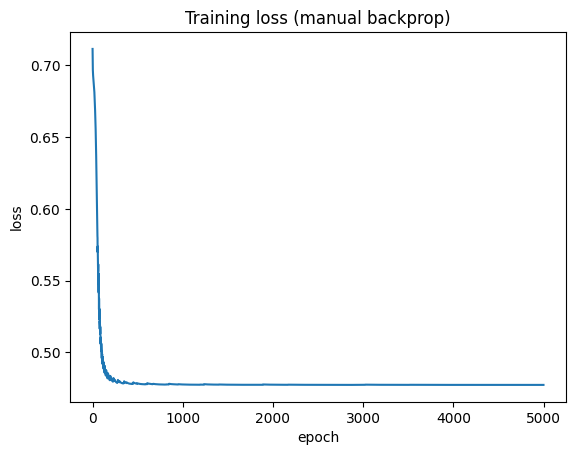

In [118]:

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss (manual backprop)")
plt.show()